## 1. What this notebook computes

The 28 **scaled commutators** $S^{ab} = \tfrac14[\gamma^a, \gamma^b] =
\tfrac14(\gamma^a\gamma^b - \gamma^b\gamma^a)$ of the author's eight real
$16 \times 16$ gamma matrices are called the *generators*. Do they generate the
group Pin(4,4)? This notebook gives the exact answer, with every step written out
and checked on the matrices:

1. the $S^{ab}$ are 28 independent matrices; the way each of them moves the eight
   coordinate directions is an $8 \times 8$ matrix $M^{ab}$, and the 28 matrices
   $M^{ab}$ form a basis of the Lie algebra so(4,4) and have the same commutators
   as the $S^{ab}$;
2. every exponential $\exp(\theta S^{ab})$ is a product $\gamma^a\gamma(u)$ of two
   unit vectors, so it lies in Spin(4,4), the even part of Pin(4,4);
3. the products of exponentials form a group, written $\mathrm{Spin}_0(4,4)$, whose
   elements are all joined to $1$ by a path. It is **not** all of Pin(4,4), and not
   even all of Spin(4,4): the space block and the time block of the matrix by which
   such an element moves the directions both have determinant at least $1$, while
   $\gamma^{(x8)}$, $\gamma^{(x4)}$ and $\gamma^{(x8)}\gamma^{(x4)}$ give the other
   three combinations of signs;
4. every unit vector $\gamma(v)$ equals $h\gamma^{(x8)}h^{-1}$ or
   $h\gamma^{(x4)}h^{-1}$ with $h$ a product of at most seven exponentials (an
   explicit construction, tested on 40 random unit vectors);
5. therefore every element of Pin(4,4) is a product of exponentials times exactly
   one of $1$, $\gamma^{(x8)}$, $\gamma^{(x4)}$, $\gamma^{(x8)}\gamma^{(x4)}$
   (tested on 12 random elements): Pin(4,4) consists of four pieces, and it is
   generated by the exponentials of the scaled commutators **together with the two
   gammas** $\gamma^{(x8)}$ and $\gamma^{(x4)}$;
6. the elements of $\mathrm{Spin}_0(4,4)$ span the 128 block-diagonal matrices and
   those of Pin(4,4) all 256 matrices, the ranks recorded in the Revision record.

Every check that repeats a recorded check prints the record file and the check
name. Six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05f (What the scaled commutators generate: Spin_0(4,4), and with two gammas all
of Pin(4,4)) is the file `Revision/textbook/notebooks/05f_pin_generation.ipynb` of the
repository Dirac_claude. It answers exactly the question whether the 28 scaled
commutators S^ab = (1/4)(gamma^a gamma^b - gamma^b gamma^a) generate Pin(4,4). It checks
that they are 28 independent matrices whose action on the eight directions is a basis of
so(4,4) with the same commutators, writes every exponential exp(theta S^ab) as a product
of two unit vectors, proves with the space and time blocks of the vector matrices that
the products of exponentials form only the part Spin_0(4,4) of Pin(4,4) that is joined to
1, constructs for every unit vector v a product h of exponentials with gamma(v) = h
gamma^(x8) h^-1 or h gamma^(x4) h^-1, and so writes every element of Pin(4,4) as a
product of exponentials times one of 1, gamma^(x8), gamma^(x4) and gamma^(x8) gamma^(x4).
Six teaching plots. It needs a computer with Windows 11, macOS or Linux, an internet
connection for the installation, the program Git, and Python 3.12 or newer (the notebooks
were built with Python 3.14.5) with these packages at exactly these versions: numpy
2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4,
nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy,
sympy and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05f_pin_generation.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05f_pin_generation.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05f_pin_generation.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/05f.captions.json`
- `Revision/textbook/figures/05f_1_generator_matrices.png`
- `Revision/textbook/figures/05f_2_two_unit_vectors.png`
- `Revision/textbook/figures/05f_3_four_pieces.png`
- `Revision/textbook/figures/05f_4_paths_and_band.png`
- `Revision/textbook/figures/05f_5_carrying_vectors.png`
- `Revision/textbook/figures/05f_6_span_ranks.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the six figure files of notebook 05f exist
    ALL 24 CHECKS PASSED (notebook 05f)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05f_pin_generation.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`: the notebook was
  opened outside the repository, or the repository is incomplete; clone the repository
  again and open the notebook from its folder `Revision/textbook/notebooks`.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05f (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05f (What the scaled commutators generate: Spin_0(4,4), and with two gammas
# all of Pin(4,4)) is the file Revision/textbook/notebooks/05f_pin_generation.ipynb of
# the repository Dirac_claude. It answers exactly the question whether the 28 scaled
# commutators S^ab = (1/4)(gamma^a gamma^b - gamma^b gamma^a) generate Pin(4,4). It
# checks that they are 28 independent matrices whose action on the eight directions is a
# basis of so(4,4) with the same commutators, writes every exponential exp(theta S^ab) as
# a product of two unit vectors, proves with the space and time blocks of the vector
# matrices that the products of exponentials form only the part Spin_0(4,4) of Pin(4,4)
# that is joined to 1, constructs for every unit vector v a product h of exponentials
# with gamma(v) = h gamma^(x8) h^-1 or h gamma^(x4) h^-1, and so writes every element of
# Pin(4,4) as a product of exponentials times one of 1, gamma^(x8), gamma^(x4) and
# gamma^(x8) gamma^(x4). Six teaching plots. It needs a computer with Windows 11, macOS
# or Linux, an internet connection for the installation, the program Git, and Python 3.12
# or newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05f_pin_generation.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05f_pin_generation.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05f_pin_generation.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/05f.captions.json
# - Revision/textbook/figures/05f_1_generator_matrices.png
# - Revision/textbook/figures/05f_2_two_unit_vectors.png
# - Revision/textbook/figures/05f_3_four_pieces.png
# - Revision/textbook/figures/05f_4_paths_and_band.png
# - Revision/textbook/figures/05f_5_carrying_vectors.png
# - Revision/textbook/figures/05f_6_span_ranks.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the six figure files of notebook 05f exist
#     ALL 24 CHECKS PASSED (notebook 05f)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05f_pin_generation.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra: the notebook was
#   opened outside the repository, or the repository is incomplete; clone the repository
#   again and open the notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05f"  # this notebook: chapter 05, example f


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05f complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Commutator** $[X, Y] = XY - YX$ of two matrices.
- **Unit vector**: eight numbers $v = (v_{x1}, \dots, v_{x8})$ with metric product
  $\eta(v, v) = \sum_a \eta_{aa} v_a^2 = +1$ (*space-like*) or $-1$ (*time-like*);
  $\eta_{aa} = +1$ for $x1, x2, x3, x8$ and $-1$ for $x4, x5, x6, x7$. The basic
  unit vectors are $e_{x1}, \dots, e_{x8}$ (one entry 1, the others 0).
- $\gamma(v) = \sum_a v_a\gamma^a$; it obeys $\gamma(v)\gamma(v) = \eta(v, v)\,1$.
- **Pin(4,4)**: all products $\gamma(u_1)\gamma(u_2)\cdots\gamma(u_k)$ of unit
  vectors ($k = 0, 1, 2, \dots$). **Spin(4,4)**: those with an even number $k$ of
  factors (the *even* elements; the others are *odd*).
- **Exponential** of a matrix: $\exp(X) = 1 + X + X^2/2 + X^3/6 + \dots =
  \sum_{k \ge 0} X^k/k!$.
- **$\mathrm{Spin}_0(4,4)$**: all products of exponentials $\exp(\theta S^{ab})$.
  It is a group: the product of two products is a product, and the inverse of
  $\exp(\theta S^{ab})$ is $\exp(-\theta S^{ab})$.
- **Generated by**: the group *generated by* some matrices is the set of all
  products of these matrices and their inverses.
- **O(4,4)**: the real $8 \times 8$ matrices $\Lambda$ with $\Lambda^T\eta\Lambda =
  \eta$ (they keep the metric product); **SO(4,4)**: those with determinant $+1$.
- **so(4,4)**: the real $8 \times 8$ matrices $X$ with $X^T\eta + \eta X = 0$ (the
  *Lie algebra* of O(4,4)).
- **Rotation, boost**: the exponential $\exp(\theta S^{ab})$ of a plane of two
  directions of the same kind (rotation, angle $\theta$) or of different kinds
  (boost, rapidity $\theta$).
- **Vector matrix** $\Lambda(g)$: the $8 \times 8$ matrix with
  $\alpha(g)\gamma^c g^{-1} = \sum_d \Lambda_{dc}\gamma^d$, where $\alpha(g) = g$
  for an even and $-g$ for an odd $g$ (the *twisted* action).
- **Reflection** $R_u$ along a unit vector $u$: $R_u v = v - 2\eta(u, v)u/
  \eta(u, u)$; it reverses $u$ and keeps every direction orthogonal to $u$.
- **Space block, time block**: with the directions ordered $x1, x2, x3, x8$ (space)
  and then $x4, x5, x6, x7$ (time), a vector matrix splits into four $4 \times 4$
  blocks $\Lambda = \begin{pmatrix} A & B \\ C & D \end{pmatrix}$; $A$ is the
  *space block* and $D$ the *time block*.
- **Sign pattern** of $g$: the pair $(\mathrm{sign}\det A, \mathrm{sign}\det D)$.
- **Rank** of a list of matrices: the number of independent ones among them;
  **span**: all their combinations.

## 4. The physical and mathematical situation

**(A) The generators move the directions.** For $a \neq b$ the gammas anticommute,
so $S^{ab} = \tfrac12\gamma^a\gamma^b$. Using the Clifford relation
$\gamma^b\gamma^c = -\gamma^c\gamma^b + 2\eta^{bc}$ and then $\gamma^a\gamma^c =
-\gamma^c\gamma^a + 2\eta^{ac}$:

$$\gamma^a\gamma^b\gamma^c = -\gamma^a\gamma^c\gamma^b + 2\eta^{bc}\gamma^a
  = \gamma^c\gamma^a\gamma^b - 2\eta^{ac}\gamma^b + 2\eta^{bc}\gamma^a .$$

Halving gives the **vector rule** $[S^{ab}, \gamma^c] = \eta^{bc}\gamma^a -
\eta^{ac}\gamma^b = \sum_d M^{ab}_{dc}\gamma^d$ with the $8 \times 8$ matrix

$$M^{ab}_{dc} = \eta^{bc}\delta_{da} - \eta^{ac}\delta_{db}$$

($\delta_{da}$ is 1 for $d = a$ and 0 otherwise). Exactly two entries are
nonzero: row $a$, column $b$ holds $\eta_{bb}$; row $b$, column $a$ holds
$-\eta_{aa}$.

**(B) so(4,4).** $X^T\eta + \eta X = 0$ says that $\eta X$ is antisymmetric
(because $(\eta X)^T = X^T\eta$). An antisymmetric $8 \times 8$ matrix is fixed by
its $8 \cdot 7/2 = 28$ entries above the diagonal, so so(4,4) has dimension 28.
For $M^{ab}$: $(\eta M^{ab})_{ab} = \eta_{aa}\eta_{bb}$ and $(\eta M^{ab})_{ba} =
-\eta_{bb}\eta_{aa}$: antisymmetric, so $M^{ab}$ lies in so(4,4).

**(C) Commutators go to commutators.** Expanding both sides shows the *Jacobi
identity* $[[X, Y], Z] = [X, [Y, Z]] - [Y, [X, Z]]$ (each side is $XYZ - YXZ -
ZXY + ZYX$). If $[S_1, \gamma^c] = \sum_d (M_1)_{dc}\gamma^d$ and the same for
$S_2$, then $[S_1, [S_2, \gamma^c]] = \sum_d (M_2)_{dc}[S_1, \gamma^d] =
\sum_e (M_1M_2)_{ec}\gamma^e$, and the Jacobi identity gives
$[[S_1, S_2], \gamma^c] = \sum_e ([M_1, M_2])_{ec}\gamma^e$: the matrix of a
commutator is the commutator of the matrices. So the 28 independent $S^{ab}$ and
the 28 independent $M^{ab}$ (a basis of so(4,4)) have the same commutation table:
the $S^{ab}$ span an exact copy of so(4,4).

**(D) Each exponential is a product of two unit vectors.** For a rotation
($\eta_{aa}\eta_{bb} = +1$), $(\gamma^a\gamma^b)^2 = -1$ and the power series gives
$\exp(\theta S^{ab}) = \cos\tfrac\theta2 + \sin\tfrac\theta2\,\gamma^a\gamma^b$;
for a boost, $(\gamma^a\gamma^b)^2 = +1$ and $\exp(\theta S^{ab}) =
\cosh\tfrac\theta2 + \sinh\tfrac\theta2\,\gamma^a\gamma^b$. Because
$\gamma^a\gamma^a = \eta_{aa}$ and $\eta_{aa}^2 = 1$,

$$\gamma^a\big(\eta_{aa}\cos\tfrac\theta2\,\gamma^a + \sin\tfrac\theta2\,
  \gamma^b\big) = \cos\tfrac\theta2 + \sin\tfrac\theta2\,\gamma^a\gamma^b ,$$

so $\exp(\theta S^{ab}) = \gamma^a\gamma(u)$ with $u = \eta_{aa}\cos\tfrac\theta2
\,e_a + \sin\tfrac\theta2\,e_b$ and $\eta(u, u) = \eta_{aa}\cos^2\tfrac\theta2 +
\eta_{bb}\sin^2\tfrac\theta2 = \eta_{aa}$. For a boost, $u = \eta_{aa}\cosh
\tfrac\theta2\,e_a + \sinh\tfrac\theta2\,e_b$ and $\eta(u, u) = \eta_{aa}
(\cosh^2 - \sinh^2) = \eta_{aa}$, since $\eta_{bb} = -\eta_{aa}$. Two unit
vectors: the exponential lies in Spin(4,4).

**(E) How an exponential moves the directions.** Put $R(\theta) = \exp(\theta
S)$ and $F_c(\theta) = R\gamma^cR^{-1}$. Since $dR/d\theta = SR = RS$ and
$d(R^{-1})/d\theta = -SR^{-1}$, the product rule gives $dF_c/d\theta =
R[S, \gamma^c]R^{-1} = \sum_d M_{dc}F_d$, with $F_c(0) = \gamma^c$. This linear
system is solved by the matrix exponential: $\Lambda(R(\theta)) = \exp(\theta M)$.
From the two entries of $M^{ab}$: $Me_a = -\eta_{aa}e_b$ and $Me_b = \eta_{bb}
e_a$, so $M^2e_a = -\eta_{aa}\eta_{bb}e_a$ and

$$\Lambda e_a = \cos\theta\, e_a - \eta_{aa}\sin\theta\, e_b \ \text{(rotation)},
  \qquad \Lambda e_a = \cosh\theta\, e_a - \eta_{aa}\sinh\theta\, e_b
  \ \text{(boost)} .$$

**(F) The forbidden band.** Every vector matrix keeps the metric,
$\Lambda^T\eta\Lambda = \eta$. In the space/time block form, $\eta =
\mathrm{diag}(1_4, -1_4)$, and the top-left block of this equation reads
$A^TA - C^TC = 1_4$ (the bottom-right one $D^TD - B^TB = 1_4$). For every column
$w$ of four numbers, $w^TA^TAw = w^Tw + w^TC^TCw$, that is $|Aw|^2 = |w|^2 +
|Cw|^2 \geq |w|^2$. So every eigenvalue of the symmetric matrix $A^TA$ is at least
1, and $(\det A)^2 = \det(A^TA) \geq 1$: **$\det A$ is never between $-1$ and
$1$**, and the same holds for $\det D$.

**(G) Products of exponentials stay above the band.** For $h = \exp(\theta_1
S_1)\cdots\exp(\theta_n S_n)$ put $h(t) = \exp(t\theta_1 S_1)\cdots\exp(t\theta_n
S_n)$, $0 \le t \le 1$: a path from $h(0) = 1$ (with $\det A = 1$) to $h(1) = h$.
The entries of $\Lambda(h(t))$ are sums of products of $\cos$, $\sin$, $\cosh$,
$\sinh$ of multiples of $t$, so $\det A(t)$ is a continuous function of $t$. It
starts at 1 and can never enter the band, so by the intermediate value theorem it
stays $\geq 1$; the same for $\det D$. **Every element of
$\mathrm{Spin}_0(4,4)$ has the sign pattern $(+, +)$.**

**(H) Four pieces.** $\Lambda(\gamma^{(x8)}) = R_{e_{x8}}$ reverses only $x8$:
pattern $(-, +)$. $\Lambda(\gamma^{(x4)})$ reverses only $x4$: $(+, -)$.
$\Lambda(\gamma^{(x8)}\gamma^{(x4)})$ reverses both: $(-, -)$. For $h$ in
$\mathrm{Spin}_0(4,4)$ and $w$ one of these, $\Lambda(hw) = \Lambda(h)
\Lambda(w)$, and $\Lambda(w)$ is a diagonal matrix of signs: it only changes the
sign of some columns of $\Lambda(h)$, so the space block of $hw$ is $A$ times a
diagonal matrix of signs and $hw$ has the pattern of $w$. Different patterns, so
the four sets $\mathrm{Spin}_0$, $\mathrm{Spin}_0\gamma^{(x8)}$,
$\mathrm{Spin}_0\gamma^{(x4)}$, $\mathrm{Spin}_0\gamma^{(x8)}\gamma^{(x4)}$ have no
element in common. In particular $\gamma^{(x8)}\gamma^{(x4)}$ lies in Spin(4,4) but
is **not** a product of exponentials.

**(I) Every unit vector is a turned basic one.** Let $v$ be a space-like unit
vector, with space part $\sigma$ (components $x1, x2, x3, x8$) and time part
$\tau$ (components $x4, \dots, x7$), so $|\sigma|^2 - |\tau|^2 = 1$. Three stages
carry $e_{x8}$ to $v$: a boost in the plane $(x8, x4)$ gives $|\sigma|e_{x8} +
|\tau|e_{x4}$; three rotations in the planes $(x4, x5)$, $(x4, x6)$, $(x4, x7)$
turn $e_{x4}$ into $\tau/|\tau|$ and do not touch $x8$; three rotations in the
planes $(x8, x1)$, $(x8, x2)$, $(x8, x3)$ turn $e_{x8}$ into $\sigma/|\sigma|$ and
do not touch the time part. The result is $\sigma + \tau = v$. The angles follow
from (E). For an even $h$, $h\gamma^{(x8)}h^{-1} = \gamma(\Lambda(h)e_{x8}) =
\gamma(v)$. A time-like $v$ is treated in the same way, starting from $e_{x4}$.

**(J) Moving the gammas to the right.** Moving $\gamma^e$ through $\gamma^a
\gamma^b$ costs $(-1)^2 = +1$ when $e$ is neither $a$ nor $b$, and $-1$ when $e$
is one of them. So $\gamma^e S^{ab}(\gamma^e)^{-1} = sS^{ab}$ with that sign $s$,
and, term by term in the power series, $\gamma^e\exp(\theta S^{ab}) =
\exp(s\theta S^{ab})\gamma^e$. A product of unit vectors, each written as in (I),
becomes a product of exponentials followed by a word in $\gamma^{(x8)}$ and
$\gamma^{(x4)}$; with $\gamma^{(x8)}\gamma^{(x8)} = 1$, $\gamma^{(x4)}\gamma^{(x4)}
= -1$, $\gamma^{(x4)}\gamma^{(x8)} = -\gamma^{(x8)}\gamma^{(x4)}$ and $-1 =
\exp(2\pi S^{(x1)(x2)})$, the word becomes one of $1$, $\gamma^{(x8)}$,
$\gamma^{(x4)}$, $\gamma^{(x8)}\gamma^{(x4)}$.

**The answer.** By (D) the exponentials, and by definition $\gamma^{(x8)}$ and
$\gamma^{(x4)}$, lie in Pin(4,4); by (I) and (J) every element of Pin(4,4) is a
product of them; by (G) and (H) the four pieces are different. So

$$\mathrm{Pin}(4,4) = \mathrm{Spin}_0 \cup \mathrm{Spin}_0\gamma^{(x8)} \cup
  \mathrm{Spin}_0\gamma^{(x4)} \cup \mathrm{Spin}_0\gamma^{(x8)}\gamma^{(x4)} ,$$

and $\mathrm{Spin}(4,4)$ is the union of the first and the last piece. The
exponentials of the scaled commutators generate exactly $\mathrm{Spin}_0(4,4)$;
together with $\gamma^{(x8)}$ and $\gamma^{(x4)}$ they generate all of Pin(4,4).

## 5. The gammas and the recorded checks

The next cell reads the gammas (exact whole numbers) from the record
`Revision/algebra/gammas.json` and the two algebra reports. It defines the lists
`SPACE` and `TIME` of the four space-like and the four time-like directions, the
$8 \times 8$ metric `ETA_MATRIX`, and the helpers `recorded(key, name)` (true when
the report `key`, "python" or "wolfram", holds the check `name` with the verdict
pass), `record_of(key, name)` (the text printed after "reproduces") and
`check_reproduces(condition, name, record)`, the helper `check` for a check that
reproduces a Revision record: it lets `check` print the PASS line and the line
"reproduces ..." into a text buffer (`contextlib.redirect_stdout`) and sends both
lines with one `sys.stdout.write`, because Jupyter delivers printed text in pieces
and one piece keeps the two lines together for the tools that read the notebook.
Then it checks the Clifford relation.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer io.StringIO
import sys  # sys.stdout: the channel through which the notebook prints

import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # +1 space-like, -1 time-like
ETA_MATRIX = np.diag([float(ETA[x]) for x in COORDS])  # the 8 x 8 metric eta
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the 16 x 16 identity matrix 1
SPACE = ["x1", "x2", "x3", "x8"]  # the four space-like directions
TIME = ["x4", "x5", "x6", "x7"]  # the four time-like directions

REPORT_FILES = {"python": "Revision/algebra/reports/python-algebra.json",
                "wolfram": "Revision/algebra/reports/wolfram-algebra.json"}
VERDICTS = {}  # (report key, check name) -> (verdict in lower case, detail text)
for key, path in REPORT_FILES.items():
    report_data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in report_data["checks"]:
        VERDICTS[(key, entry["name"])] = (entry["verdict"].lower(), entry["detail"])


def recorded(key, name):
    """True when the report key records the check name with the verdict pass."""
    return VERDICTS[(key, name)][0] == "pass"


def record_of(key, name):
    """The text printed after "reproduces": the record file and the check name."""
    return f"{REPORT_FILES[key]}, check {name}"


def check_reproduces(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    collected = io.StringIO()
    with contextlib.redirect_stdout(collected):  # print into the buffer
        check(condition, name, record=record)  # stops here if the check fails
    sys.stdout.write(collected.getvalue())  # the PASS and reproduces lines together


def eta(a, b):
    """eta^ab of the frame metric: eta_aa when a = b, 0 otherwise."""
    return ETA[a] if a == b else 0


check_reproduces(all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                                    2 * eta(a, b) * I16) for a in COORDS for b in COORDS)
                 and recorded("python", "clifford_relation"),
                 "{gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs",
                 record=record_of("python", "clifford_relation"))

PASS {gamma^a, gamma^b} = 2 eta^ab 1 for all 64 pairs
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation


## 6. The 28 scaled commutators are independent

The next cell builds $S^{ab} = \tfrac14[\gamma^a, \gamma^b]$ for all 64 ordered
pairs (so $S^{aa} = 0$ and $S^{ba} = -S^{ab}$) as arrays of floating-point numbers;
their entries are $0$ and $\pm\tfrac12$, which the computer stores exactly. The
list `pairs` holds the 28 planes $(a, b)$ with $a$ before $b$ in the order
$x1, \dots, x8$. To test independence **exactly**, it writes each whole-number
matrix $2S^{ab} = \gamma^a\gamma^b$ as one row of 256 numbers and computes the rank
of the 28 rows with sympy's `DomainMatrix` over the rational numbers `QQ`
(Gaussian elimination with fractions): rank 28 means that no $S^{ab}$ is a
combination of the others.

In [3]:
import sympy as sp  # exact algebra
from sympy.polys.matrices import DomainMatrix  # exact matrices over QQ

S = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4.0
     for a in COORDS for b in COORDS}  # all 64 ordered pairs; S^aa = 0
pairs = [(a, b) for i, a in enumerate(COORDS) for b in COORDS[i + 1:]]  # 28 planes


def exact_rank(rows):
    """The rank of a list of rows of whole numbers, computed exactly over QQ."""
    whole = [[int(round(x)) for x in row] for row in rows]  # entries 0, +1, -1
    return DomainMatrix.from_list(whole, sp.QQ).rank()


rank_S = exact_rank([(gamma[a] @ gamma[b]).reshape(256) for a, b in pairs])
entries = sorted({float(v) for p in pairs for v in S[p].flat})
say(f"{len(pairs)} generators; their entries are {entries}; exact rank {rank_S}")
check_reproduces(rank_S == 28 and entries == [-0.5, 0.0, 0.5]
                 and all(np.array_equal(S[(a, b)], gamma[a] @ gamma[b] / 2.0)
                         for a, b in pairs)
                 and recorded("python", "S_definition"),
                 "the 28 S^ab = (1/2) gamma^a gamma^b are linearly independent "
                 "(exact rank 28)",
                 record=record_of("python", "S_definition"))

28 generators; their entries are [-0.5, 0.0, 0.5]; exact rank 28
PASS the 28 S^ab = (1/2) gamma^a gamma^b are linearly independent (exact rank 28)
     reproduces Revision/algebra/reports/python-algebra.json, check S_definition


## 7. How the scaled commutators move the directions: a copy of so(4,4)

The next cell builds, for all 64 ordered pairs, the $8 \times 8$ matrix $M^{ab}$ of
section 4 (A), rows $d$ and columns $c$ in the order $x1, \dots, x8$, and checks
three things:

1. the vector rule $[S^{ab}, \gamma^c] = \sum_d M^{ab}_{dc}\gamma^d$ for the 28
   planes and the 8 directions $c$ (a recorded fact);
2. every $M^{ab}$ obeys $(M^{ab})^T\eta + \eta M^{ab} = 0$; the 28 of them are
   independent (exact rank 28); and the space so(4,4) has dimension exactly 28:
   the condition $X^T\eta + \eta X = 0$ is a system of 64 linear equations for the
   64 entries of an unknown $X$, with $(\eta X)_{rc} = \eta_{rr}X_{rc}$ and
   $(X^T\eta)_{rc} = X_{cr}\eta_{cc}$, whose solutions form a space of dimension
   64 minus the rank. So the $M^{ab}$ are a **basis** of so(4,4);
3. the commutators of the $M^{ab}$ follow the same table as those of the
   $S^{ab}$, $[X^{ab}, X^{cd}] = \eta^{bc}X^{ad} - \eta^{ac}X^{bd} -
   \eta^{bd}X^{ac} + \eta^{ad}X^{bc}$, for all $28 \times 28 = 784$ pairs (for the
   $S^{ab}$ a recorded fact).

In [4]:
def generator_matrix(a, b):
    """The 8 x 8 matrix M^ab with [S^ab, gamma^c] = sum over d of M_dc gamma^d:
    M_dc = eta^bc delta_da - eta^ac delta_db (rows d, columns c: x1, ..., x8)."""
    result = np.zeros((8, 8))
    for j, c in enumerate(COORDS):
        for i, d in enumerate(COORDS):
            result[i, j] = eta(b, c) * (d == a) - eta(a, c) * (d == b)
    return result


M = {(a, b): generator_matrix(a, b) for a in COORDS for b in COORDS}  # all 64
vector_ok = all(
    np.array_equal(S[p] @ gamma[c] - gamma[c] @ S[p],
                   sum(M[p][i, j] * gamma[d] for i, d in enumerate(COORDS)))
    for p in pairs for j, c in enumerate(COORDS))
check_reproduces(vector_ok and recorded("python", "S_vector_action")
                 and recorded("wolfram", "S_gamma_commutator"),
                 "[S^ab, gamma^c] = sum_d M^ab_dc gamma^d with M_dc = eta^bc delta_da "
                 "- eta^ac delta_db",
                 record=record_of("python", "S_vector_action"))

in_so44 = all(not (M[p].T @ ETA_MATRIX + ETA_MATRIX @ M[p]).any() for p in pairs)
rank_M = exact_rank([M[p].reshape(64) for p in pairs])
equations = []  # the 64 equations (X^T eta + eta X)_rc = 0 for the entries of X
for r in range(8):
    for c in range(8):
        row = np.zeros(64)
        row[r * 8 + c] += ETA_MATRIX[r, r]  # (eta X)_rc = eta_rr X_rc
        row[c * 8 + r] += ETA_MATRIX[c, c]  # (X^T eta)_rc = X_cr eta_cc
        equations.append(row)
dimension_so44 = 64 - exact_rank(equations)
say(f"rank of the 28 matrices M^ab: {rank_M}; dimension of so(4,4): "
    f"{dimension_so44}")
check(in_so44 and rank_M == 28 and dimension_so44 == 28,
      "every M^ab lies in so(4,4), the 28 M^ab are independent and so(4,4) has "
      "dimension 28: the M^ab are a basis of so(4,4)")


def table_failures(X):
    """How many of the 784 pairs of planes break the commutation table for the
    64 matrices X[(a, b)]."""
    failures = 0
    for a, b in pairs:
        for c, d in pairs:
            right = (eta(b, c) * X[(a, d)] - eta(a, c) * X[(b, d)]
                     - eta(b, d) * X[(a, c)] + eta(a, d) * X[(b, c)])
            if not np.array_equal(X[(a, b)] @ X[(c, d)] - X[(c, d)] @ X[(a, b)],
                                  right):
                failures += 1
    return failures


failures_S, failures_M = table_failures(S), table_failures(M)
say(f"pairs that break the table: S^ab {failures_S}, M^ab {failures_M} (of 784)")
check_reproduces(failures_S == 0 and failures_M == 0
                 and recorded("python", "S_lorentz_algebra")
                 and recorded("wolfram", "S_Lorentz_algebra"),
                 "the S^ab and the M^ab have the same commutators: the S^ab span an "
                 "exact copy of so(4,4)",
                 record=record_of("python", "S_lorentz_algebra"))

PASS [S^ab, gamma^c] = sum_d M^ab_dc gamma^d with M_dc = eta^bc delta_da - eta^ac
    delta_db
     reproduces Revision/algebra/reports/python-algebra.json, check S_vector_action
rank of the 28 matrices M^ab: 28; dimension of so(4,4): 28
PASS every M^ab lies in so(4,4), the 28 M^ab are independent and so(4,4) has dimension
    28: the M^ab are a basis of so(4,4)
pairs that break the table: S^ab 0, M^ab 0 (of 784)
PASS the S^ab and the M^ab have the same commutators: the S^ab span an exact copy of
    so(4,4)
     reproduces Revision/algebra/reports/python-algebra.json, check S_lorentz_algebra


The next cell checks the shape of the 28 matrices that section 4 (A) predicts
(exactly two nonzero entries; antisymmetric for the 12 rotations, symmetric for the
16 boosts) and draws them, one small heat map per plane.

PASS each M^ab has two nonzero entries; antisymmetric for the 12 rotations, symmetric for
    the 16 boosts


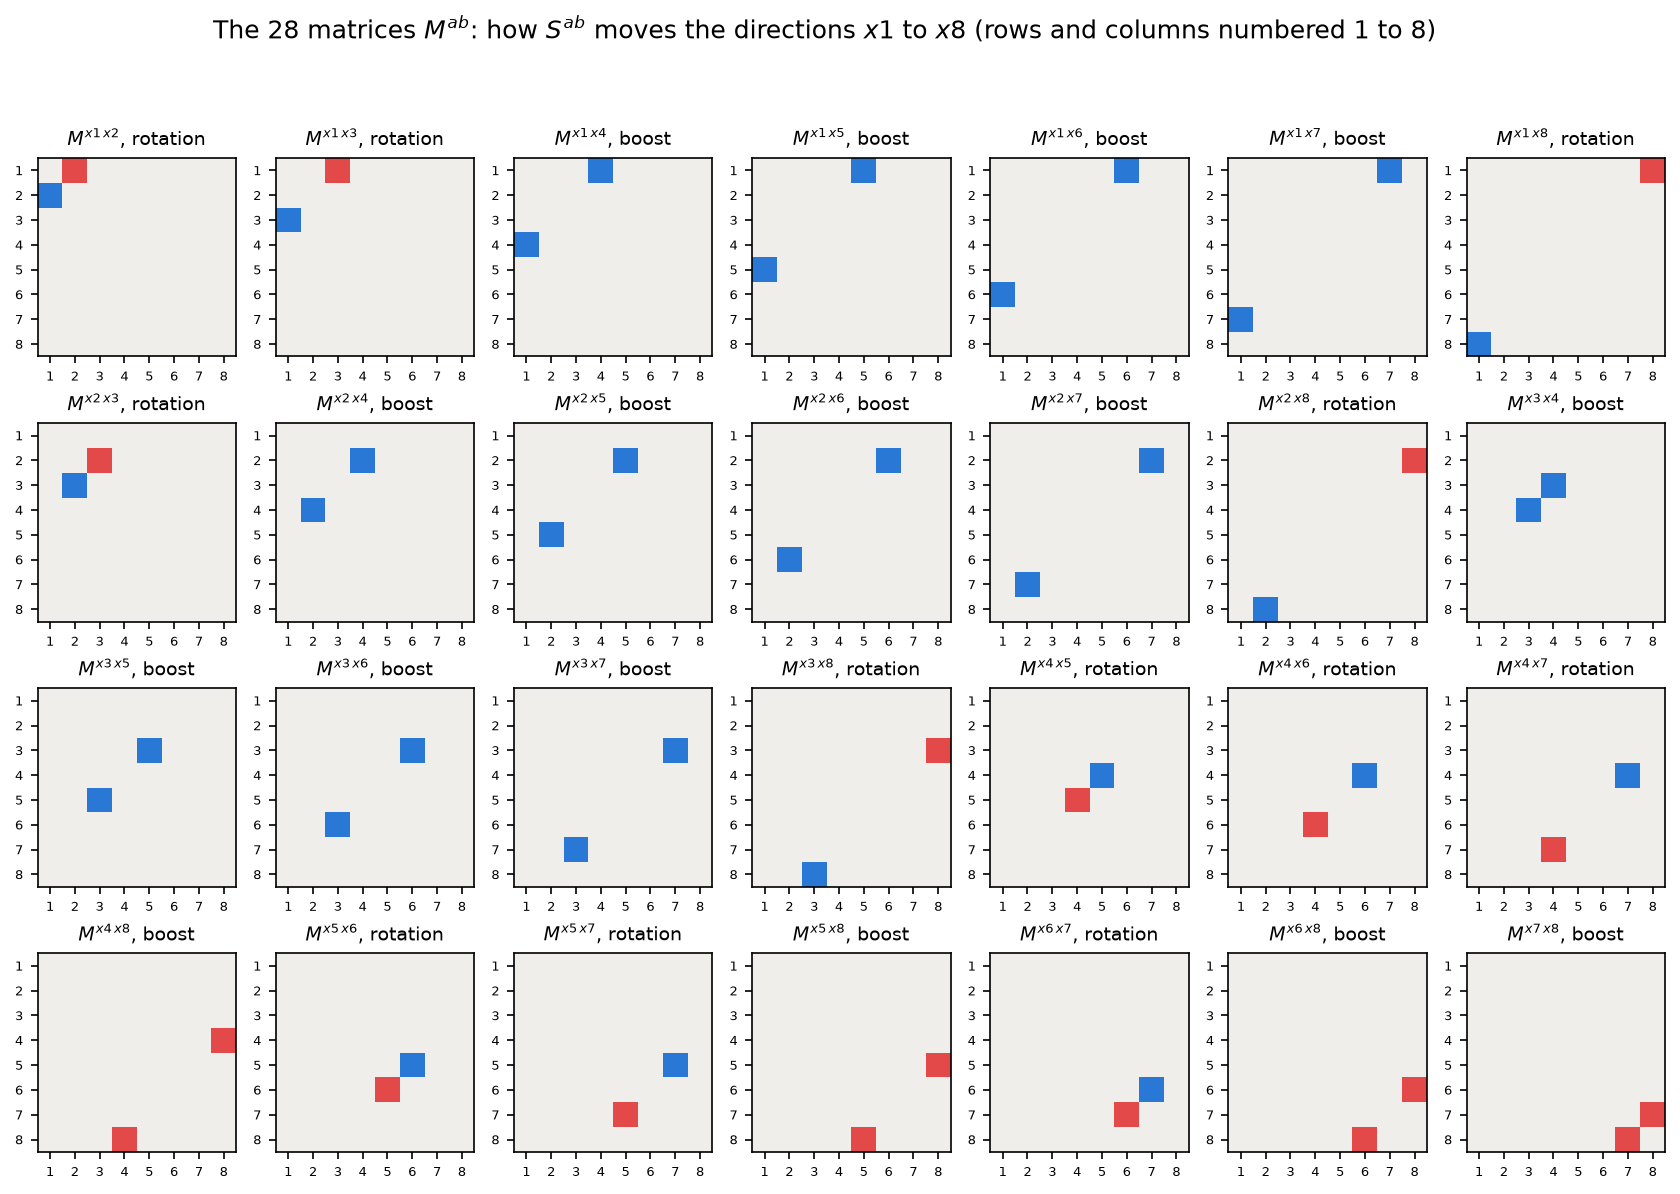

Figure 05f.1 saved as Revision/textbook/figures/05f_1_generator_matrices.png


In [5]:
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
shape_ok = all(
    np.count_nonzero(M[(a, b)]) == 2
    and np.array_equal(M[(a, b)].T, -ETA[a] * ETA[b] * M[(a, b)]) for a, b in pairs)
check(shape_ok, "each M^ab has two nonzero entries; antisymmetric for the 12 "
      "rotations, symmetric for the 16 boosts")
fig, axes = plt.subplots(4, 7, figsize=(14.0, 8.8))
numbers = [x[1] for x in COORDS]  # the tick labels 1, ..., 8
for ax, (a, b) in zip(axes.flat, pairs):
    ax.imshow(M[(a, b)], cmap=SIGNS, vmin=-1, vmax=1)
    kind = "rotation" if ETA[a] * ETA[b] == 1 else "boost"
    ax.set_title(f"$M^{{{a}\\,{b}}}$, {kind}", fontsize=9)
    ax.set_xticks(range(8), numbers, fontsize=6)
    ax.set_yticks(range(8), numbers, fontsize=6)
    ax.grid(False)
fig.suptitle("The 28 matrices $M^{ab}$: how $S^{ab}$ moves the directions "
             "$x1$ to $x8$ (rows and columns numbered 1 to 8)")
save_figure(fig, "generator_matrices",
            "The 28 eight by eight matrices $M^{ab}$ by which the scaled commutators "
            "$S^{ab}$ move the eight directions, one picture per plane $(a, b)$; rows "
            "and columns are the directions $x1$ to $x8$, labelled by their number; "
            "red $+1$, blue $-1$, grey $0$. Each has exactly two nonzero entries, in "
            "row $a$ column $b$ and in row $b$ column $a$: of opposite colour "
            "(antisymmetric) for the 12 rotations, of the same colour (symmetric) for "
            "the 16 boosts that mix a space-like and a time-like direction. These 28 "
            "matrices are a basis of so(4,4).")

## 8. Every exponential is a product of two unit vectors

The next cell defines `exponential(a, b, theta)`, the closed formula of section 4
(D) for $\exp(\theta S^{ab})$, and compares it with the power series summed up to
60 terms for all 28 planes at $\theta = 0.9$. Then, for all 28 planes and the five
values $\theta = -2.5, -0.4, 0.9, 2.2, 5.0$, it forms the vector $u$ of section 4
(D) and checks $\exp(\theta S^{ab}) = \gamma^a\gamma(u)$ and $\eta(u, u) =
\eta_{aa}$. `gamma_of(v)` is $\gamma(v)$ and `metric_product(u, v)` is
$\eta(u, v)$; `E8[i]` is the basic unit vector of the direction `COORDS[i]`.

In [6]:
def exponential(a, b, theta):
    """exp(theta S^ab) from the closed formula with half angles (any a != b)."""
    J = (gamma[a] @ gamma[b]).astype(float)  # J = 2 S^ab, J J = -eta_aa eta_bb
    if ETA[a] * ETA[b] == 1:  # J J = -1: a rotation
        return np.cos(theta / 2) * np.eye(16) + np.sin(theta / 2) * J
    return np.cosh(theta / 2) * np.eye(16) + np.sinh(theta / 2) * J  # a boost


def series_exponential(X, terms=60):
    """exp(X) = 1 + X + X^2/2 + ... summed up to X^(terms-1)/(terms-1)!."""
    result = np.eye(X.shape[0])
    term = np.eye(X.shape[0])
    for k in range(1, terms):
        term = term @ X / k  # X^k / k! from X^(k-1) / (k-1)!
        result = result + term
    return result


def gamma_of(v):
    """gamma(v) = sum over a of v_a gamma^a for a vector v of 8 numbers."""
    return sum(v[i] * gamma[x].astype(float) for i, x in enumerate(COORDS))


def metric_product(u, v):
    """eta(u, v) = sum over a of eta_aa u_a v_a."""
    return float(u @ ETA_MATRIX @ v)


def second_factor(a, b, theta):
    """The unit vector u with exp(theta S^ab) = gamma^a gamma(u) (section 4 D)."""
    i, j = COORDS.index(a), COORDS.index(b)
    if ETA[a] * ETA[b] == 1:  # a rotation
        return ETA[a] * np.cos(theta / 2) * E8[i] + np.sin(theta / 2) * E8[j]
    return ETA[a] * np.cosh(theta / 2) * E8[i] + np.sinh(theta / 2) * E8[j]


E8 = np.eye(8)  # E8[i] is the basic unit vector of the direction COORDS[i]
series_gap = max(np.max(np.abs(series_exponential(0.9 * S[p]) - exponential(*p, 0.9)))
                 for p in pairs)
check(series_gap < 1e-10, "the closed formula equals the power series of "
      "exp(theta S^ab) for all 28 planes (difference below 1e-10)")
factor_ok = True
for a, b in pairs:
    for theta in [-2.5, -0.4, 0.9, 2.2, 5.0]:
        u = second_factor(a, b, theta)
        factor_ok &= (np.allclose(gamma[a] @ gamma_of(u), exponential(a, b, theta),
                                  rtol=0.0, atol=1e-10)
                      and abs(metric_product(u, u) - ETA[a]) < 1e-10)
check(factor_ok, "exp(theta S^ab) = gamma^a gamma(u) with eta(u, u) = eta_aa: a "
      "product of two unit vectors (28 planes, 5 values each)")

PASS the closed formula equals the power series of exp(theta S^ab) for all 28 planes
    (difference below 1e-10)
PASS exp(theta S^ab) = gamma^a gamma(u) with eta(u, u) = eta_aa: a product of two unit
    vectors (28 planes, 5 values each)


The next cell draws where the second unit vector $u$ of the factorisation lies, in
the plane of its two nonzero components, for three planes: the rotation in
$(x1, x2)$ ($\theta$ from 0 to $4\pi$; $u$ runs once around the circle $u_1^2 +
u_2^2 = 1$), the boost in $(x1, x4)$ and the boost in $(x4, x8)$ ($\theta$ from
$-3$ to 3; $u$ runs along a branch of a hyperbola).

PASS along the three curves eta(u, u) stays equal to eta_aa


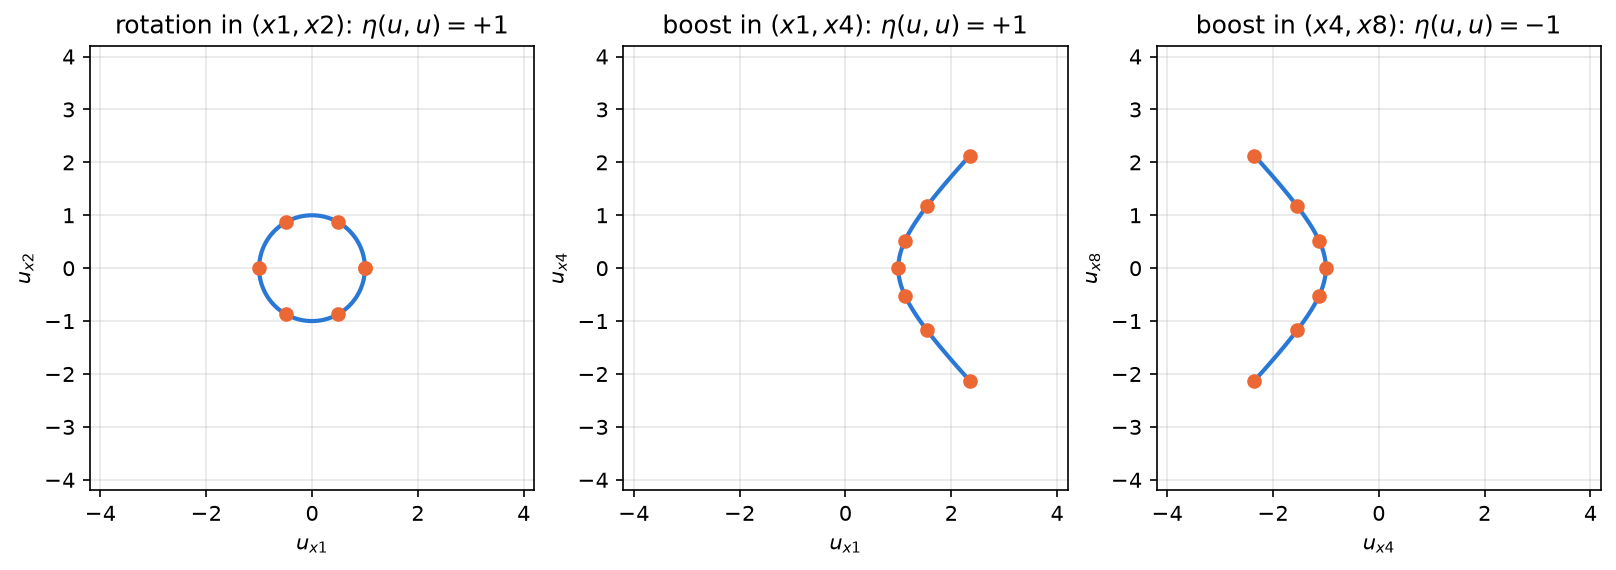

Figure 05f.2 saved as Revision/textbook/figures/05f_2_two_unit_vectors.png


In [7]:
cases = [("x1", "x2", np.linspace(0.0, 4 * np.pi, 241)),
         ("x1", "x4", np.linspace(-3.0, 3.0, 241)),
         ("x4", "x8", np.linspace(-3.0, 3.0, 241))]
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.6))
norm_ok = True  # eta(u, u) = eta_aa along all three curves
for ax, (a, b, thetas) in zip(axes, cases):
    points = np.array([second_factor(a, b, th) for th in thetas])
    i, j = COORDS.index(a), COORDS.index(b)
    norms = [metric_product(p, p) for p in points]
    norm_ok &= max(abs(n - ETA[a]) for n in norms) < 1e-10
    ax.plot(points[:, i], points[:, j], color="#2a78d6", linewidth=2)
    marks = points[::40]  # every 40th value of theta
    ax.plot(marks[:, i], marks[:, j], "o", color="#eb6834", markersize=6)
    kind = "rotation" if ETA[a] * ETA[b] == 1 else "boost"
    ax.set_title(f"{kind} in $({a}, {b})$: $\\eta(u, u) = {norms[0]:+.0f}$")
    ax.set_xlabel(f"$u_{{{a}}}$")
    ax.set_ylabel(f"$u_{{{b}}}$")
    ax.set_aspect("equal")
    ax.set_xlim(-4.2, 4.2)
    ax.set_ylim(-4.2, 4.2)
check(norm_ok, "along the three curves eta(u, u) stays equal to eta_aa")
save_figure(fig, "two_unit_vectors",
            "The second factor $u$ in $\\exp(\\theta S^{ab}) = \\gamma^a\\gamma(u)$, "
            "drawn in the plane of its two nonzero components (axes: the components "
            "of $u$, pure numbers; orange dots every 40th value of $\\theta$). Left: "
            "the rotation in the plane $(x1, x2)$, $\\theta$ from $0$ to $4\\pi$; $u$ "
            "runs once around the unit circle. Middle and right: the boosts in the "
            "planes $(x1, x4)$ and $(x4, x8)$, $\\theta$ from $-3$ to $3$; $u$ runs "
            "along a branch of a hyperbola. In every case $\\eta(u, u)$ stays $+1$ or "
            "$-1$: each exponential is a product of two unit vectors.")

## 9. The vector matrix of an exponential is exp(theta M)

The next cell defines `vector_matrix(g, odd)`, the vector matrix $\Lambda(g)$ of
the words list: it computes $\alpha(g)\gamma^cg^{-1}$ for each direction $c$ and
reads off $\Lambda_{dc} = \eta_{dd}\,\mathrm{tr}(\gamma^d\alpha(g)\gamma^cg^{-1})/16$
(because $\mathrm{tr}(\gamma^d\gamma^e) = 16\eta^{de}$). It checks, for all 28 planes
at $\theta = 0.9$, that $\Lambda(\exp(\theta S^{ab})) = \exp(\theta M^{ab})$ (the
matrix exponential summed as a power series), that it keeps the metric
($\Lambda^T\eta\Lambda = \eta$) and has determinant 1. Then it checks the turning
formulas of section 4 (E) for four planes used later: the rotations in
$(x8, x1)$ and $(x4, x5)$ and the boosts in $(x8, x4)$ and $(x4, x8)$.

In [8]:
def vector_matrix(g, odd=False):
    """Lambda(g) with alpha(g) gamma^c g^-1 = sum over d of Lambda_dc gamma^d, where
    alpha(g) = g for an even g and -g for an odd g (the twisted action)."""
    g_inverse = np.linalg.inv(g)
    sign = -1.0 if odd else 1.0
    result = np.zeros((8, 8))
    for j, c in enumerate(COORDS):
        moved = sign * (g @ gamma[c] @ g_inverse)  # alpha(g) gamma^c g^-1
        for i, d in enumerate(COORDS):
            result[i, j] = ETA[d] * np.trace(gamma[d] @ moved) / 16.0
    return result


exp_ok = True
for p in pairs:
    Lam = vector_matrix(exponential(*p, 0.9))
    exp_ok &= (np.allclose(Lam, series_exponential(0.9 * M[p]), rtol=0.0, atol=1e-12)
               and np.allclose(Lam.T @ ETA_MATRIX @ Lam, ETA_MATRIX, atol=1e-12)
               and abs(np.linalg.det(Lam) - 1.0) < 1e-12)
check(exp_ok, "the vector matrix of exp(theta S^ab) is exp(theta M^ab); it keeps "
      "the metric and has determinant 1 (28 planes)")


def turned_axis(a, b, theta):
    """Lambda e_a predicted by section 4 E for exp(theta S^ab)."""
    i, j = COORDS.index(a), COORDS.index(b)
    if ETA[a] * ETA[b] == 1:  # a rotation
        return np.cos(theta) * E8[i] - ETA[a] * np.sin(theta) * E8[j]
    return np.cosh(theta) * E8[i] - ETA[a] * np.sinh(theta) * E8[j]  # a boost


turn_ok = all(
    np.allclose(vector_matrix(exponential(a, b, th))[:, COORDS.index(a)],
                turned_axis(a, b, th), rtol=0.0, atol=1e-12)
    for a, b in [("x8", "x1"), ("x4", "x5"), ("x8", "x4"), ("x4", "x8")]
    for th in [-1.3, 0.4, 2.0])
check(turn_ok, "Lambda e_a = cos(theta) e_a - eta_aa sin(theta) e_b for a rotation "
      "and cosh(theta) e_a - eta_aa sinh(theta) e_b for a boost")

PASS the vector matrix of exp(theta S^ab) is exp(theta M^ab); it keeps the metric and has
    determinant 1 (28 planes)
PASS Lambda e_a = cos(theta) e_a - eta_aa sin(theta) e_b for a rotation and cosh(theta)
    e_a - eta_aa sinh(theta) e_b for a boost


## 10. The forbidden band and the four pieces

The next cell defines `blocks(Lam)`, which cuts a vector matrix into the space
block $A$, the blocks $B$ and $C$ and the time block $D$ (`np.ix_` picks the rows
and columns of the listed directions), and `random_factors(count)`: `count` random
factors $(a, b, \theta)$, each a random plane of the 28 with an angle between 0 and
$2\pi$ for a rotation and a rapidity between $-1$ and 1 for a boost, drawn by the
random-number generator with the fixed seed 12345 (so every run uses the same
numbers). `compose(factors, t)` is the product $\exp(t\theta_n S_n)\cdots
\exp(t\theta_1 S_1)$, in which the first factor of the list acts first. For 200
random products of six exponentials the cell checks the block equations
$A^TA - C^TC = 1$ and $D^TD - B^TB = 1$ of section 4 (F) and that $\det A$ and
$\det D$ are at least 1 (section 4 G).

In [9]:
SPACE_INDEX = [COORDS.index(x) for x in SPACE]  # the positions of x1, x2, x3, x8
TIME_INDEX = [COORDS.index(x) for x in TIME]  # the positions of x4, x5, x6, x7


def blocks(Lam):
    """The blocks A (space, space), B (space, time), C (time, space), D (time,
    time) of the 8 x 8 matrix Lam."""
    return (Lam[np.ix_(SPACE_INDEX, SPACE_INDEX)], Lam[np.ix_(SPACE_INDEX, TIME_INDEX)],
            Lam[np.ix_(TIME_INDEX, SPACE_INDEX)], Lam[np.ix_(TIME_INDEX, TIME_INDEX)])


rng = np.random.default_rng(12345)  # random numbers with a fixed seed


def random_factors(count):
    """count random factors (a, b, theta) of a product of exponentials."""
    factors = []
    for _ in range(count):
        a, b = pairs[int(rng.integers(28))]  # a random plane
        if ETA[a] * ETA[b] == 1:  # a rotation: an angle from 0 to 2 pi
            theta = rng.uniform(0.0, 2 * np.pi)
        else:  # a boost: a rapidity from -1 to 1
            theta = rng.uniform(-1.0, 1.0)
        factors.append((a, b, float(theta)))
    return factors


def compose(factors, t=1.0):
    """exp(t theta_n S_n) ... exp(t theta_1 S_1): the first factor acts first."""
    g = np.eye(16)
    for a, b, theta in factors:
        g = exponential(a, b, t * theta) @ g
    return g


block_ok, smallest = True, np.inf
for _ in range(200):
    A, B_, C_, D = blocks(vector_matrix(compose(random_factors(6))))
    block_ok &= (np.allclose(A.T @ A - C_.T @ C_, np.eye(4), atol=1e-9)
                 and np.allclose(D.T @ D - B_.T @ B_, np.eye(4), atol=1e-9))
    smallest = min(smallest, np.linalg.det(A), np.linalg.det(D))
report("smallest det A or det D of 200 products of six exponentials",
       f"{smallest:.3f}")
check(block_ok and smallest > 1.0 - 1e-9,
      "200 products of exponentials: A^T A - C^T C = 1, D^T D - B^T B = 1, and "
      "det A >= 1, det D >= 1")

RESULT smallest det A or det D of 200 products of six exponentials = 1.019
PASS 200 products of exponentials: A^T A - C^T C = 1, D^T D - B^T B = 1, and det A >= 1,
    det D >= 1


The next cell computes the vector matrices of the four words $1$, $\gamma^{(x8)}$,
$\gamma^{(x4)}$ and $\gamma^{(x8)}\gamma^{(x4)}$ (the gammas are odd, their
product even) and checks that they are the diagonal sign matrices of section 4
(H). Then, for each word $w$ and 60 random products $h$ of six exponentials, it
checks $\Lambda(hw) = \Lambda(h)\Lambda(w)$ and that $hw$ has the sign pattern of
$w$. It also records an observation that the picture shows but the proof does not
use: for each of the 240 elements $|\det A| = |\det D|$ (to $10^{-9}$). The next
cell draws all 240 points $(\det A, \det D)$. The axes are *symmetric
logarithmic*: linear between $-1$ and $1$ and logarithmic outside, so that the
forbidden band (shaded) is visible.

In [10]:
WORDS = {"1": (I16, False), "gamma^(x8)": (gamma["x8"], True),
         "gamma^(x4)": (gamma["x4"], True),
         "gamma^(x8) gamma^(x4)": (gamma["x8"] @ gamma["x4"], False)}


def pattern(Lam):
    """(sign of det A, sign of det D) of the vector matrix Lam."""
    A, _, _, D = blocks(Lam)
    return (int(np.sign(np.linalg.det(A))), int(np.sign(np.linalg.det(D))))


flip8 = np.diag([1.0, 1, 1, 1, 1, 1, 1, -1])  # reverses x8 only
flip4 = np.diag([1.0, 1, 1, -1, 1, 1, 1, 1])  # reverses x4 only
expected = {"1": np.eye(8), "gamma^(x8)": flip8, "gamma^(x4)": flip4,
            "gamma^(x8) gamma^(x4)": flip8 @ flip4}
words_ok = all(np.allclose(vector_matrix(w.astype(float), odd), expected[name])
               for name, (w, odd) in WORDS.items())
for name, (w, odd) in WORDS.items():
    say(f"{name:22} sign pattern (sign det A, sign det D) = "
        f"{pattern(vector_matrix(w.astype(float), odd))}")
check(words_ok, "the vector matrices of 1, gamma^(x8), gamma^(x4), gamma^(x8) "
      "gamma^(x4) are the identity and the reversals of x8, x4 and both")
points = {}  # word -> list of (det A, det D)
pieces_ok = True
for name, (w, odd) in WORDS.items():
    points[name] = []
    Lam_w = vector_matrix(w.astype(float), odd)
    for _ in range(60):
        h = compose(random_factors(6))
        Lam = vector_matrix(h @ w, odd)
        pieces_ok &= (np.allclose(Lam, vector_matrix(h) @ Lam_w, atol=1e-9)
                      and pattern(Lam) == pattern(Lam_w))
        A, _, _, D = blocks(Lam)
        points[name].append((np.linalg.det(A), np.linalg.det(D)))
check(pieces_ok, "for 4 x 60 elements h w: Lambda(h w) = Lambda(h) Lambda(w), and h w "
      "has the sign pattern of w")
# An observation that the picture below shows and that the proof does not need:
# for every one of the 240 elements the two determinants have the same size.
equal_size = all(abs(abs(dA) - abs(dD)) < 1e-9 * max(abs(dA), 1.0)
                 for name in WORDS for dA, dD in points[name])
check(equal_size, "observed for all 240 elements: |det A| = |det D|")

1                      sign pattern (sign det A, sign det D) = (1, 1)
gamma^(x8)             sign pattern (sign det A, sign det D) = (-1, 1)
gamma^(x4)             sign pattern (sign det A, sign det D) = (1, -1)
gamma^(x8) gamma^(x4)  sign pattern (sign det A, sign det D) = (-1, -1)
PASS the vector matrices of 1, gamma^(x8), gamma^(x4), gamma^(x8) gamma^(x4) are the
    identity and the reversals of x8, x4 and both
PASS for 4 x 60 elements h w: Lambda(h w) = Lambda(h) Lambda(w), and h w has the sign
    pattern of w
PASS observed for all 240 elements: |det A| = |det D|


The next cell draws the 240 points.

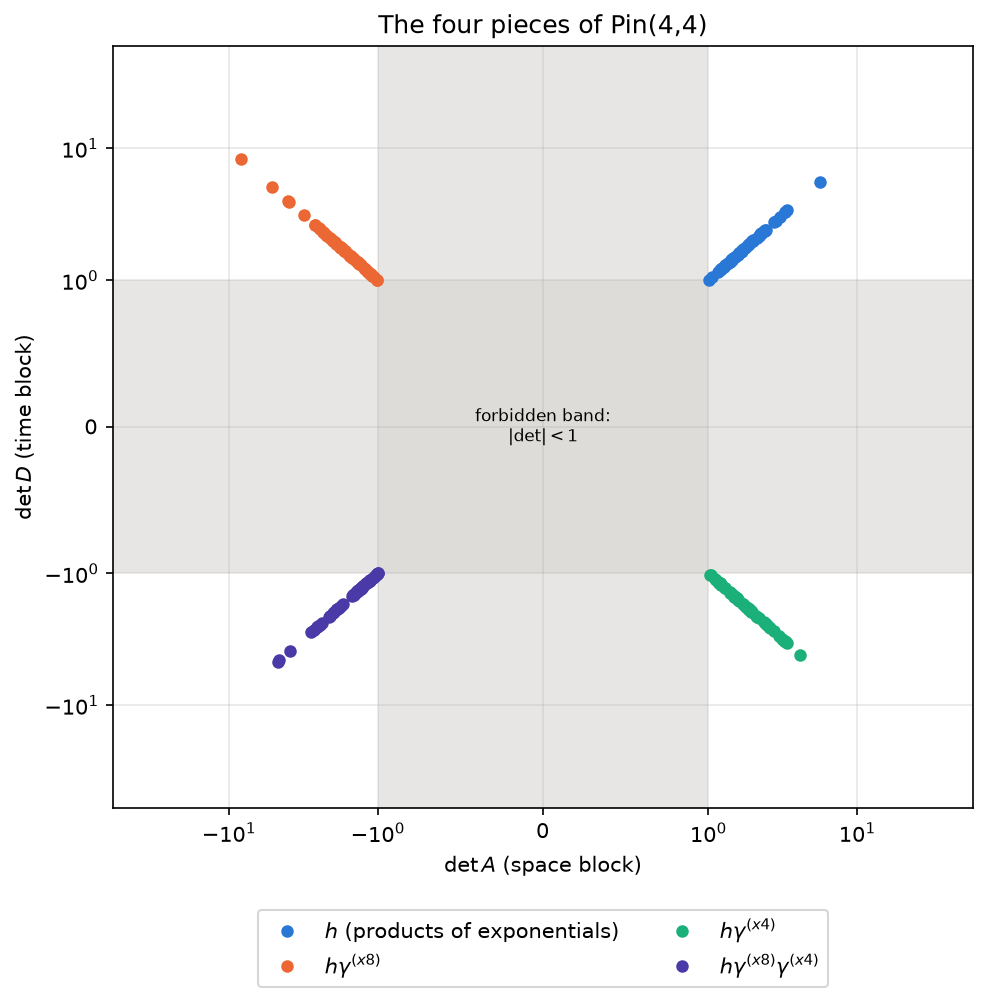

Figure 05f.3 saved as Revision/textbook/figures/05f_3_four_pieces.png


In [11]:
colors = {"1": "#2a78d6", "gamma^(x8)": "#eb6834", "gamma^(x4)": "#1baf7a",
          "gamma^(x8) gamma^(x4)": "#4a3aa7"}
labels = {"1": r"$h$ (products of exponentials)",
          "gamma^(x8)": r"$h\gamma^{(x8)}$",
          "gamma^(x4)": r"$h\gamma^{(x4)}$",
          "gamma^(x8) gamma^(x4)": r"$h\gamma^{(x8)}\gamma^{(x4)}$"}
fig, ax = plt.subplots(figsize=(7.4, 6.6))
ax.axvspan(-1.0, 1.0, color="#d8d6d2", alpha=0.6, linewidth=0)
ax.axhspan(-1.0, 1.0, color="#d8d6d2", alpha=0.6, linewidth=0)
for name in WORDS:
    values = np.array(points[name])
    ax.plot(values[:, 0], values[:, 1], "o", color=colors[name], markersize=5,
            label=labels[name])
ax.set_xscale("symlog", linthresh=1.0)
ax.set_yscale("symlog", linthresh=1.0)
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)
ax.text(0.0, 0.0, "forbidden band:\n$|\\det| < 1$", ha="center", va="center",
        fontsize=8)
ax.set_xlabel("$\\det A$ (space block)")
ax.set_ylabel("$\\det D$ (time block)")
ax.set_title("The four pieces of Pin(4,4)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
save_figure(fig, "four_pieces",
            "The determinants of the space block $A$ (horizontal axis) and of the time "
            "block $D$ (vertical axis) of the vector matrices of 240 elements of "
            "Pin(4,4): 60 random products $h$ of six exponentials (blue) and $h$ "
            "times $\\gamma^{(x8)}$ (orange), $\\gamma^{(x4)}$ (green) and "
            "$\\gamma^{(x8)}\\gamma^{(x4)}$ (purple). Both axes are linear between "
            "$-1$ and $1$ and logarithmic outside; the grey bands $|\\det| < 1$ are "
            "forbidden for every element. Each kind fills one of the four corners: "
            "the products of exponentials never leave the corner where both "
            "determinants are at least 1. The points lie on the diagonals because "
            "$|\\det A| = |\\det D|$ for every element computed here.")

## 11. Paths from 1 never cross the band

The next cell follows ten products $h$ of six exponentials along the path $h(t)$
of section 4 (G), $t = 0, 0.01, \dots, 1$, and computes $\det A(t)$; it does the
same for the odd elements $\gamma^{(x8)}h(t)$. The first family starts at $+1$ and
must stay at or above $+1$; the second starts at $-1$ and must stay at or below
$-1$. Neither can cross the band, which is why $\gamma^{(x8)}$ is not a product of
exponentials.

PASS along ten paths t -> h(t) det A stays >= 1, and along gamma^(x8) h(t) it stays <= -1


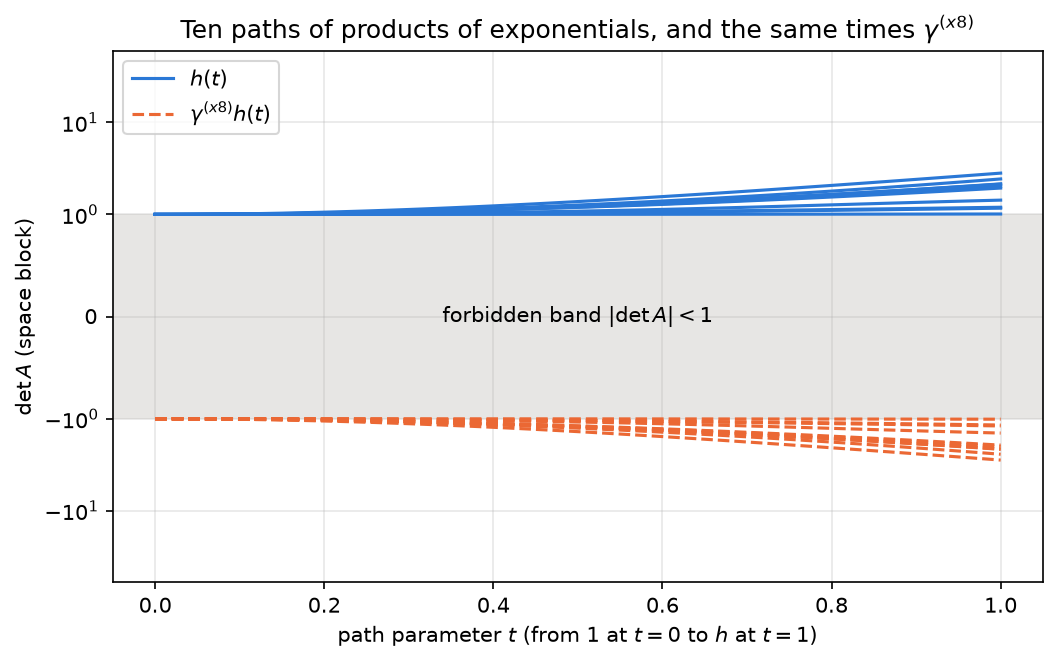

Figure 05f.4 saved as Revision/textbook/figures/05f_4_paths_and_band.png


In [12]:
path_t = np.linspace(0.0, 1.0, 101)  # t = 0, 0.01, ..., 1
curves_h, curves_g8 = [], []  # det A(t) along h(t) and along gamma^(x8) h(t)
g8 = gamma["x8"].astype(float)
for _ in range(10):
    factors = random_factors(6)
    along_h, along_g8 = [], []
    for t in path_t:
        h = compose(factors, t)
        along_h.append(np.linalg.det(blocks(vector_matrix(h))[0]))
        along_g8.append(np.linalg.det(blocks(vector_matrix(g8 @ h, odd=True))[0]))
    curves_h.append(along_h)
    curves_g8.append(along_g8)
curves_h, curves_g8 = np.array(curves_h), np.array(curves_g8)
check(np.all(curves_h > 1.0 - 1e-9) and np.all(curves_g8 < -1.0 + 1e-9)
      and np.allclose(curves_h[:, 0], 1.0) and np.allclose(curves_g8[:, 0], -1.0),
      "along ten paths t -> h(t) det A stays >= 1, and along gamma^(x8) h(t) it "
      "stays <= -1")
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.axhspan(-1.0, 1.0, color="#d8d6d2", alpha=0.6, linewidth=0)
for k in range(10):
    ax.plot(path_t, curves_h[k], color="#2a78d6", linewidth=1.5,
            label=r"$h(t)$" if k == 0 else None)
    ax.plot(path_t, curves_g8[k], color="#eb6834", linewidth=1.5, linestyle="--",
            label=r"$\gamma^{(x8)}h(t)$" if k == 0 else None)
ax.set_yscale("symlog", linthresh=1.0)
ax.set_ylim(-60, 60)
ax.text(0.5, 0.0, "forbidden band $|\\det A| < 1$", ha="center", va="center")
ax.set_xlabel("path parameter $t$ (from 1 at $t = 0$ to $h$ at $t = 1$)")
ax.set_ylabel("$\\det A$ (space block)")
ax.set_title("Ten paths of products of exponentials, and the same times "
             "$\\gamma^{(x8)}$")
ax.legend(loc="upper left")
save_figure(fig, "paths_and_band",
            "The determinant of the space block $A$ of the vector matrix along ten "
            "paths $h(t)$ from the identity ($t = 0$) to a random product $h$ of six "
            "exponentials ($t = 1$), solid blue, and along the odd elements "
            "$\\gamma^{(x8)}h(t)$, dashed orange; horizontal axis $t$, vertical axis "
            "$\\det A$ (linear between $-1$ and $1$, logarithmic outside). The blue "
            "curves start at $1$ and the orange at $-1$; the grey band $|\\det A| < "
            "1$ is forbidden for every element, so no curve can cross it: "
            "$\\gamma^{(x8)}$ is not joined to $1$ and is not a product of "
            "exponentials.")

## 12. Every unit vector is a turned gamma^(x8) or gamma^(x4)

The next cell implements the construction of section 4 (I).
`turn_factor(a, b, along_a, along_b)` returns the factor $(a, b, \theta)$ whose
vector matrix carries $e_a$ to the direction of $\text{along}_a e_a +
\text{along}_b e_b$: from (E), for a rotation $\theta =
\mathrm{atan2}(-\eta_{aa}\text{along}_b, \text{along}_a)$ (`np.arctan2(y, x)` is
the angle of the point $(x, y)$, so $\cos\theta$ and $\sin\theta$ are proportional
to $x$ and $y$), and for a boost (which needs $\text{along}_a^2 -
\text{along}_b^2 = 1$) $\theta = \mathrm{arcsinh}(-\eta_{aa}\text{along}_b)$.
`block_rotation(axis, others, n)` carries $e_{\text{axis}}$ to the unit vector $n$
of one block by three rotations: the first turns part of the axis into the first
other direction, keeping on the axis the length $\sqrt{n_{\text{axis}}^2 +
\text{(squares of the remaining components)}}$, and so on; the last leaves exactly
$n_{\text{axis}}$ (which may be negative). `carry(v)` returns the factors (the
first acts first) and the starting direction, $x8$ for a space-like and $x4$ for a
time-like $v$. The cell checks the construction on 40 random unit vectors: each is
a random column of 8 numbers from the normal distribution, kept when $|\eta(w,
w)| \geq 0.5$ and divided by $\sqrt{|\eta(w, w)|}$. The checks: $\Lambda(h)e = v$
and, as $16 \times 16$ matrices, $h\gamma^eh^{-1} = \gamma(v)$.

In [13]:
def turn_factor(a, b, along_a, along_b):
    """The factor (a, b, theta) whose vector matrix carries e_a to the direction of
    along_a e_a + along_b e_b (for a boost: along_a^2 - along_b^2 = 1)."""
    if ETA[a] * ETA[b] == 1:  # a rotation
        return (a, b, float(np.arctan2(-ETA[a] * along_b, along_a)))
    return (a, b, float(np.arcsinh(-ETA[a] * along_b)))  # a boost


def block_rotation(axis, others, n):
    """Three rotations, in the planes (axis, others[k]), that carry e_axis to the
    unit vector n of its block (n: direction -> component)."""
    factors = []
    for k, b in enumerate(others):
        if k < len(others) - 1:  # keep the length of the rest on the axis
            rest = np.sqrt(n[axis] ** 2 + sum(n[o] ** 2 for o in others[k + 1:]))
        else:  # the last rotation leaves exactly n_axis on the axis
            rest = n[axis]
        factors.append(turn_factor(axis, b, rest, n[b]))
    return factors


def carry(v):
    """(factors, e): a product h of exponentials (the first factor acts first)
    with Lambda(h) e_e = v; e = "x8" for a space-like, "x4" for a time-like v."""
    part = {x: float(v[COORDS.index(x)]) for x in COORDS}
    sigma = np.sqrt(sum(part[x] ** 2 for x in SPACE))  # length of the space part
    tau = np.sqrt(sum(part[x] ** 2 for x in TIME))  # length of the time part
    space_turn = block_rotation("x8", ["x1", "x2", "x3"],
                                {x: part[x] / sigma for x in SPACE}) if sigma else []
    time_turn = block_rotation("x4", ["x5", "x6", "x7"],
                               {x: part[x] / tau for x in TIME}) if tau else []
    if metric_product(v, v) > 0:  # space-like: from e_x8
        return [turn_factor("x8", "x4", sigma, tau)] + time_turn + space_turn, "x8"
    return [turn_factor("x4", "x8", tau, sigma)] + space_turn + time_turn, "x4"


def random_unit_vector():
    """A random unit vector (|eta(w, w)| >= 0.5 before it is divided)."""
    while True:
        w = rng.normal(size=8)  # eight numbers from the normal distribution
        q = metric_product(w, w)
        if abs(q) >= 0.5:
            return w / np.sqrt(abs(q))


starts = {"x8": 0, "x4": 0}  # how many space-like and time-like vectors
carry_ok, most_factors = True, 0
for _ in range(40):
    v = random_unit_vector()
    factors, e = carry(v)
    starts[e] += 1
    most_factors = max(most_factors, len(factors))
    h = compose(factors)
    carry_ok &= (np.allclose(vector_matrix(h)[:, COORDS.index(e)], v, atol=1e-12)
                 and np.allclose(h @ gamma[e] @ np.linalg.inv(h), gamma_of(v),
                                 atol=1e-12))
say(f"space-like vectors: {starts['x8']}; time-like vectors: {starts['x4']}; "
    f"at most {most_factors} exponentials per vector")
check(carry_ok and starts["x8"] > 0 and starts["x4"] > 0 and most_factors <= 7,
      "for 40 random unit vectors v: gamma(v) = h gamma^(e) h^-1 with h a product "
      "of at most 7 exponentials and e = x8 or x4")

space-like vectors: 20; time-like vectors: 20; at most 7 exponentials per vector
PASS for 40 random unit vectors v: gamma(v) = h gamma^(e) h^-1 with h a product of at
    most 7 exponentials and e = x8 or x4


The next cell draws the construction at work for one space-like and one
time-like random unit vector: the eight components of the moving vector after each
of the seven exponentials (step 0 is the starting vector $e_{x8}$ or $e_{x4}$; the
dots at the right are the components of $v$). It also prints the seven factors of
the space-like example and checks that the metric product of the moving vector
stays $+1$ (or $-1$) at every step.

    factor exp(theta S^(x8 x4)), theta = -0.6277
    factor exp(theta S^(x4 x5)), theta = -0.9366
    factor exp(theta S^(x4 x6)), theta = +0.5742
    factor exp(theta S^(x4 x7)), theta = -2.5727
    factor exp(theta S^(x8 x1)), theta = -0.2291
    factor exp(theta S^(x8 x2)), theta = +0.0009
    factor exp(theta S^(x8 x3)), theta = -1.1305
PASS in both examples the moving vector keeps eta(w, w) and ends at v


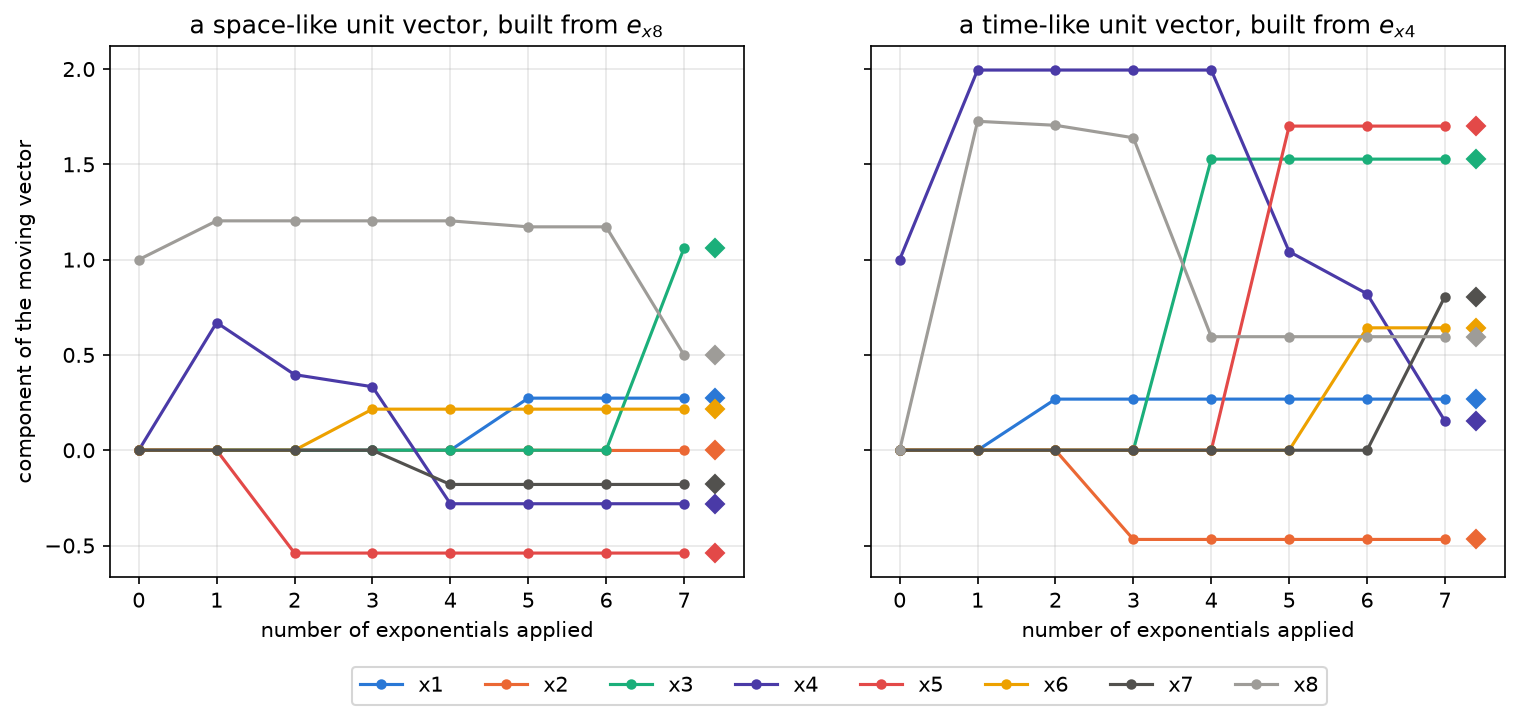

Figure 05f.5 saved as Revision/textbook/figures/05f_5_carrying_vectors.png


In [14]:
examples = [random_unit_vector() for _ in range(6)]
space_example = next(v for v in examples if metric_product(v, v) > 0)
time_example = next(v for v in examples if metric_product(v, v) < 0)
line_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948", "#eda100",
               "#52514e", "#9e9c98"]
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharey=True)
steps_ok = True
for ax, v in zip(axes, [space_example, time_example]):
    factors, e = carry(v)
    moving = [E8[COORDS.index(e)]]  # the vector after 0, 1, ..., 7 steps
    for a, b, theta in factors:
        moving.append(vector_matrix(exponential(a, b, theta)) @ moving[-1])
    moving = np.array(moving)
    steps_ok &= np.allclose([metric_product(m, m) for m in moving], ETA[e])
    steps_ok &= np.allclose(moving[-1], v, atol=1e-12)
    if e == "x8":
        for a, b, theta in factors:
            say(f"    factor exp(theta S^({a} {b})), theta = {theta:+.4f}")
    for i, x in enumerate(COORDS):
        ax.plot(range(len(moving)), moving[:, i], "o-", color=line_colors[i],
                linewidth=1.5, markersize=4, label=x)
        ax.plot([len(moving) - 0.6], [v[i]], "D", color=line_colors[i],
                markersize=6)
    kind = "space-like" if e == "x8" else "time-like"
    ax.set_title(f"a {kind} unit vector, built from $e_{{{e}}}$")
    ax.set_xticks(range(len(moving)))
    ax.set_xlabel("number of exponentials applied")
axes[0].set_ylabel("component of the moving vector")
axes[1].legend(loc="upper center", bbox_to_anchor=(-0.05, -0.15), ncol=8)
check(steps_ok, "in both examples the moving vector keeps eta(w, w) and ends at v")
save_figure(fig, "carrying_vectors",
            "The construction that carries a basic unit vector to a given unit vector "
            "$v$ by a product of exponentials: the eight components (one colour each, "
            "legend $x1$ to $x8$) of the moving vector after $0, 1, \\dots, 7$ "
            "exponentials (horizontal axis), for a random space-like $v$ built from "
            "$e_{x8}$ (left) and a random time-like $v$ built from $e_{x4}$ (right). "
            "The first step is a boost that shares the length between $x8$ and $x4$, "
            "the next three turn one block and the last three the other; the "
            "diamonds at the right are the components of $v$, which the last step "
            "reaches. Vertical axis: the components, pure numbers.")

## 13. Every element of Pin(4,4) is a product of exponentials times one of four

The next cell checks the rule of section 4 (J): $\gamma^e\exp(\theta S^{ab})
(\gamma^e)^{-1} = \exp(s\theta S^{ab})$ with $s = -1$ when $e$ is $a$ or $b$ and
$s = +1$ otherwise, for $e = x8, x4$ and all 28 planes.

In [15]:
def conjugation_sign(e, a, b):
    """The sign s with gamma^e exp(theta S^ab) (gamma^e)^-1 = exp(s theta S^ab)."""
    return -1 if e in (a, b) else 1


conjugation_ok = all(
    np.allclose(gamma[e] @ exponential(a, b, 0.8) @ np.linalg.inv(gamma[e]),
                exponential(a, b, conjugation_sign(e, a, b) * 0.8), atol=1e-12)
    for e in ("x8", "x4") for a, b in pairs)
check(conjugation_ok, "gamma^e exp(theta S^ab) (gamma^e)^-1 = exp(s theta S^ab), "
      "s = -1 if e is a or b, +1 otherwise")

PASS gamma^e exp(theta S^ab) (gamma^e)^-1 = exp(s theta S^ab), s = -1 if e is a or b, +1
    otherwise


The next cell writes 12 random elements $g = \gamma(v_1)\cdots\gamma(v_k)$ of
Pin(4,4) ($k = 1, \dots, 6$, twice each) in the form of section 4. A *word* is a
list of items in the order of the matrix product, each an exponential `("exp", a,
b, theta)` or a gamma `("gamma", e)`; `evaluate(word)` multiplies it out.
`word_of(v)` is the word of $\gamma(v) = h\gamma^eh^{-1}$ (with $h^{-1}$ the factors
in the opposite order with the opposite angles). `move_gammas_right(word)` moves
every gamma to the right end with the rule just checked, and `reduce_gammas`
writes the remaining product of gammas as $\pm$ one of the four words; a sign
$-1$ is replaced by the exponential $\exp(2\pi S^{(x1)(x2)}) = -1$. For each
element the cell checks that the word equals $g$, that the final product of
exponentials times the word $w$ equals $g$ (relative difference below
$10^{-9}$), and that $g$ has the sign pattern of $w$.

In [16]:
FOUR = {"1": I16, "gamma^(x8)": gamma["x8"], "gamma^(x4)": gamma["x4"],
        "gamma^(x8) gamma^(x4)": gamma["x8"] @ gamma["x4"]}


def evaluate(word):
    """The matrix product of the items of the word, from left to right."""
    g = np.eye(16)
    for item in word:
        if item[0] == "exp":
            g = g @ exponential(*item[1:])
        else:
            g = g @ gamma[item[1]]
    return g


def word_of(v):
    """The word of gamma(v) = h gamma^e h^-1 (h from the construction)."""
    factors, e = carry(v)
    h_word = [("exp", a, b, th) for a, b, th in reversed(factors)]  # E_n ... E_1
    h_inverse = [("exp", a, b, -th) for a, b, th in factors]  # E_1^-1 ... E_n^-1
    return h_word + [("gamma", e)] + h_inverse


def move_gammas_right(word):
    """(exponentials, gammas) with word = exponentials followed by the gammas."""
    exponentials, waiting = [], []  # waiting: the gammas moved to the right so far
    for item in word:
        if item[0] == "gamma":
            waiting.append(item[1])
        else:  # this exponential is moved to the left of all waiting gammas
            _, a, b, theta = item
            s = 1
            for e in waiting:
                s *= conjugation_sign(e, a, b)
            exponentials.append(("exp", a, b, s * theta))
    return exponentials, waiting


def reduce_gammas(waiting):
    """(sign, name) with the product of the gammas = sign times FOUR[name]."""
    product = I16
    for e in waiting:
        product = product @ gamma[e]
    for name, w in FOUR.items():
        if np.array_equal(product, w):
            return 1, name
        if np.array_equal(product, -w):
            return -1, name
    raise ValueError("the product of the gammas is not one of the four words")


decomposition_ok = True
for number in range(12):
    k = 1 + number % 6  # the number of unit vectors
    vectors = [random_unit_vector() for _ in range(k)]
    g = np.eye(16)
    word = []
    for v in vectors:
        g = g @ gamma_of(v)
        word += word_of(v)
    size = np.max(np.abs(g))  # for relative differences
    exponentials, waiting = move_gammas_right(word)
    sign, name = reduce_gammas(waiting)
    if sign == -1:  # -1 = exp(2 pi S^(x1 x2))
        exponentials.append(("exp", "x1", "x2", 2 * np.pi))
    rebuilt = evaluate(exponentials) @ FOUR[name]
    same_pattern = (pattern(vector_matrix(g, odd=k % 2 == 1))
                    == pattern(vector_matrix(FOUR[name].astype(float), WORDS[name][1])))
    decomposition_ok &= (np.max(np.abs(evaluate(word) - g)) < 1e-9 * size
                         and np.max(np.abs(rebuilt - g)) < 1e-9 * size
                         and same_pattern and WORDS[name][1] == (k % 2 == 1))
    plural = "s" if k > 1 else " "  # "1 unit vector", "2 unit vectors"
    say(f"element {number + 1:2d}: {k} unit vector{plural} = {len(exponentials):2d} "
        f"exponentials times {name}")
check(decomposition_ok, "12 random elements of Pin(4,4): each is a product of "
      "exponentials times one of 1, gamma^(x8), gamma^(x4), gamma^(x8) gamma^(x4), "
      "with the matching sign pattern")

element  1: 1 unit vector  = 14 exponentials times gamma^(x8)
element  2: 2 unit vectors = 29 exponentials times gamma^(x8) gamma^(x4)
element  3: 3 unit vectors = 43 exponentials times gamma^(x4)
element  4: 4 unit vectors = 56 exponentials times gamma^(x8) gamma^(x4)
element  5: 5 unit vectors = 71 exponentials times gamma^(x4)
element  6: 6 unit vectors = 85 exponentials times gamma^(x8) gamma^(x4)
element  7: 1 unit vector  = 14 exponentials times gamma^(x8)
element  8: 2 unit vectors = 28 exponentials times gamma^(x8) gamma^(x4)
element  9: 3 unit vectors = 42 exponentials times gamma^(x4)
element 10: 4 unit vectors = 56 exponentials times 1
element 11: 5 unit vectors = 71 exponentials times gamma^(x4)
element 12: 6 unit vectors = 85 exponentials times 1
PASS 12 random elements of Pin(4,4): each is a product of exponentials times one of 1,
    gamma^(x8), gamma^(x4), gamma^(x8) gamma^(x4), with the matching sign pattern


## 14. What the group elements span

The *span* of a group (all combinations of its elements) is closed under products,
because the product of two elements is an element. For $\mathrm{Spin}_0(4,4)$:
$\exp(\pi S^{ab}) = \gamma^a\gamma^b$ for a rotation ($\cos\tfrac\pi2 = 0$,
$\sin\tfrac\pi2 = 1$) and $(\exp(\theta S^{ab}) - \exp(-\theta S^{ab}))/
(2\sinh\tfrac\theta2) = \gamma^a\gamma^b$ for a boost, so the span contains every
$\gamma^a\gamma^b$, hence every product of an even number of gammas: all 128 even
Clifford products, which span the block-diagonal matrices. Every element is even,
so the span is exactly these 128 dimensions. With one gamma added, the span of
Pin(4,4) is all 256. The next cell checks the two formulas for all 28 planes and
then measures the rank of the first $n$ elements of two random lists, $n = 1, 2,
\dots$: 170 random products of six exponentials, and 300 random elements $hw$ with
$w$ running through the four words. The rank is computed from the *singular
values* (`np.linalg.svd`; a list of numbers whose count above a small threshold,
here $10^{-9}$ times the largest, is the rank).

In [17]:
formula_ok = all(
    np.allclose(exponential(a, b, np.pi), gamma[a] @ gamma[b], atol=1e-12)
    if ETA[a] * ETA[b] == 1 else
    np.allclose((exponential(a, b, 0.8) - exponential(a, b, -0.8))
                / (2 * np.sinh(0.4)), gamma[a] @ gamma[b], atol=1e-12)
    for a, b in pairs)
check(formula_ok, "exp(pi S^ab) = gamma^a gamma^b for the rotations and "
      "(exp(theta S^ab) - exp(-theta S^ab)) / (2 sinh(theta/2)) = gamma^a gamma^b "
      "for the boosts")
spin0_elements = [compose(random_factors(6)) for _ in range(170)]
four_words = list(FOUR.values())
pin_elements = [compose(random_factors(6)) @ four_words[k % 4] for k in range(300)]


def rank_curve(elements):
    """The rank of the first n elements, for n = 1, 2, ..., len(elements)."""
    ranks = []
    for n in range(1, len(elements) + 1):
        rows = np.array([g.reshape(256) for g in elements[:n]])
        singular = np.linalg.svd(rows, compute_uv=False)
        ranks.append(int(np.sum(singular > 1e-9 * singular[0])))
    return ranks


ranks_spin0, ranks_pin = rank_curve(spin0_elements), rank_curve(pin_elements)
block_diagonal = all(not g[:8, 8:].any() and not g[8:, :8].any()
                     for g in spin0_elements)
report("rank of 170 products of exponentials", ranks_spin0[-1])
report("rank of 300 elements of Pin(4,4)", ranks_pin[-1])
check_reproduces(ranks_spin0 == [min(n, 128) for n in range(1, 171)]
                 and block_diagonal
                 and recorded("python", "even_products_span_M8_plus_M8"),
                 "the products of exponentials are block diagonal and span 128 "
                 "dimensions, as the 128 even Clifford products",
                 record=record_of("python", "even_products_span_M8_plus_M8"))
check_reproduces(ranks_pin == [min(n, 256) for n in range(1, 301)]
                 and recorded("python", "clifford_products_span_M16"),
                 "the elements of Pin(4,4) span all 256 dimensions of the 16 x 16 "
                 "matrices",
                 record=record_of("python", "clifford_products_span_M16"))

PASS exp(pi S^ab) = gamma^a gamma^b for the rotations and (exp(theta S^ab) - exp(-theta
    S^ab)) / (2 sinh(theta/2)) = gamma^a gamma^b for the boosts
RESULT rank of 170 products of exponentials = 128
RESULT rank of 300 elements of Pin(4,4) = 256
PASS the products of exponentials are block diagonal and span 128 dimensions, as the 128
    even Clifford products
     reproduces Revision/algebra/reports/python-algebra.json, check
    even_products_span_M8_plus_M8
PASS the elements of Pin(4,4) span all 256 dimensions of the 16 x 16 matrices
     reproduces Revision/algebra/reports/python-algebra.json, check
    clifford_products_span_M16


The next cell draws the two rank curves.

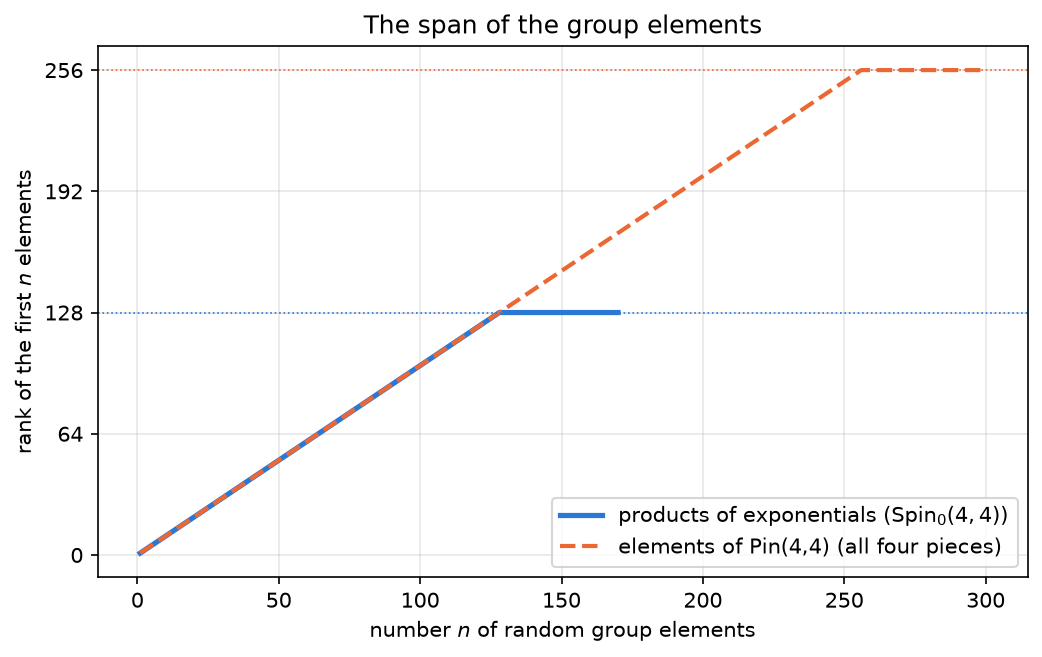

Figure 05f.6 saved as Revision/textbook/figures/05f_6_span_ranks.png


In [18]:
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(range(1, 171), ranks_spin0, color="#2a78d6", linewidth=2.5,
        label=r"products of exponentials ($\mathrm{Spin}_0(4,4)$)")
ax.plot(range(1, 301), ranks_pin, color="#eb6834", linewidth=2, linestyle="--",
        label="elements of Pin(4,4) (all four pieces)")
ax.axhline(128, color="#2a78d6", linewidth=0.8, linestyle=":")
ax.axhline(256, color="#eb6834", linewidth=0.8, linestyle=":")
ax.set_xlabel("number $n$ of random group elements")
ax.set_ylabel("rank of the first $n$ elements")
ax.set_yticks([0, 64, 128, 192, 256])
ax.set_title("The span of the group elements")
ax.legend(loc="lower right")
save_figure(fig, "span_ranks",
            "The rank of the first $n$ of a list of random group elements (vertical "
            "axis) against $n$ (horizontal axis): 170 random products of six "
            "exponentials (solid blue) and 300 random elements of all four pieces of "
            "Pin(4,4) (dashed orange). Each new element adds one dimension until the "
            "rank stops at 128 for the products of exponentials (they span exactly "
            "the block-diagonal matrices) and at 256 for Pin(4,4) (all 16 by 16 "
            "matrices), the two numbers recorded by the Revision record for the even "
            "and for all Clifford products.")

## 15. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [19]:
FIGURES = ["05f_1_generator_matrices.png", "05f_2_two_unit_vectors.png",
           "05f_3_four_pieces.png", "05f_4_paths_and_band.png",
           "05f_5_carrying_vectors.png", "05f_6_span_ranks.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the six figure files of notebook 05f exist")
all_checks_passed()

PASS the six figure files of notebook 05f exist
ALL 24 CHECKS PASSED (notebook 05f)


## 16. What this notebook showed

- PROVED (section 4, line by line) and CHECKED on the matrices: the 28 scaled
  commutators $S^{ab} = \tfrac14[\gamma^a, \gamma^b]$ of the Revision gammas are
  independent; the matrices $M^{ab}$ by which they move the eight directions are
  a basis of so(4,4) (dimension 28) with the same commutators, so the $S^{ab}$ span
  an exact copy of so(4,4). The recorded checks S_definition, S_vector_action and
  S_lorentz_algebra are reproduced.
- PROVED and CHECKED: every $\exp(\theta S^{ab}) = \gamma^a\gamma(u)$ is a product
  of two unit vectors, so the exponentials lie in Spin(4,4); its vector matrix is
  $\exp(\theta M^{ab})$.
- PROVED: the space block and the time block of every vector matrix have
  determinants outside the band $(-1, 1)$; along a path from 1 they cannot change
  sign. So all products of exponentials, the group $\mathrm{Spin}_0(4,4)$, have
  the sign pattern $(+, +)$, while $\gamma^{(x8)}$, $\gamma^{(x4)}$ and
  $\gamma^{(x8)}\gamma^{(x4)}$ have $(-, +)$, $(+, -)$, $(-, -)$.
- PROVED by an explicit construction and CHECKED on 40 random unit vectors: every
  $\gamma(v)$ is $h\gamma^{(x8)}h^{-1}$ or $h\gamma^{(x4)}h^{-1}$ with $h$ a product
  of at most seven exponentials; CHECKED on 12 random elements: every element of
  Pin(4,4) is a product of exponentials times exactly one of $1$, $\gamma^{(x8)}$,
  $\gamma^{(x4)}$, $\gamma^{(x8)}\gamma^{(x4)}$.
- THE ANSWER: the exponentials of the scaled commutators generate exactly
  $\mathrm{Spin}_0(4,4)$, the part of Pin(4,4) joined to 1; adding the two gammas
  $\gamma^{(x8)}$ and $\gamma^{(x4)}$ generates all of Pin(4,4), which has four
  pieces, and Spin(4,4) is the union of the two even pieces. It is not correct to
  say that the scaled commutators alone generate Pin(4,4).
- COMPUTED: the elements of $\mathrm{Spin}_0(4,4)$ span the 128 block-diagonal
  matrices and those of Pin(4,4) all 256, the ranks recorded for the even and for
  all Clifford products.